In [5]:
import numpy as np
import matplotlib.pyplot as plt
import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 1 - PET/Code/Methods.py'>

In [51]:
def get_transmission_efficiency(
    source_x,          # The current position of the moving source (mm)
    slit_width_W,      # The gap between the lead plates (mm)
    attenuation_len,   # Lambda for the material (mm)
    n_rays=100000       # Number of MC rays to cast
):
    """
    Calculates the fraction of rays from a point source at (source_x, 0, 0)
    that hit the scintillator, accounting for attenuation through the lead gates.
    """

    # --- Constants from your setup ---
    Z_source = 0.0
    Z_gate_start = 36.0
    Z_gate_end = 46.0  # 36 + 10mm thickness
    Z_scint = 50.0
    R_scint = 35.0     # Scintillator radius
    X_gate_left = -slit_width_W / 2.0
    X_gate_right = slit_width_W / 2.0

    minAngle =  np.arctan((source_x-R_scint)/Z_scint)
    maxAngle =  np.arctan((source_x+R_scint)/Z_scint)

    # --- 1. Generate Isotropic Rays in 3D ---
    # We only care about rays that will hit the scintillator
    # Uniform sphere sampling:
    phi = np.random.uniform(minAngle, maxAngle, n_rays)
    costheta = np.random.uniform(0, 1, n_rays) # 0 to 1 for forward hemisphere
    sintheta = np.sqrt(1 - costheta**2)

    # Ray Unit Vectors (ux, uy, uz)
    ux = sintheta * np.cos(phi)
    uy = sintheta * np.sin(phi)
    uz = costheta

    # --- 2. Geometric Cut: Check if they hit the Scintillator ---
    # Project ray to Z_scint plane
    # t_scint is the distance scalar such that source + t*u = scint_pos
    # Since source is at Z=0: t_scint * uz = Z_scint => t_scint = Z_scint / uz

    # Position at scintillator plane
    # x(z) = source_x + (z / uz) * ux
    # y(z) = 0        + (z / uz) * uy

    # Scale factor mapping Z-distance to transverse distance
    scale_scint = Z_scint / uz
    x_at_scint = source_x + scale_scint * ux
    y_at_scint = scale_scint * uy

    # Check intersection with Scintillator Disk
    hit_mask = (x_at_scint**2 + y_at_scint**2) <= R_scint**2

    # Optimization: Filter out rays that miss the detector entirely
    # We only process the 'hits' to save computation
    ux = ux[hit_mask]
    uy = uy[hit_mask]
    uz = uz[hit_mask]
    num_hits = len(uz)

    if num_hits == 0:
        return 0.0

    # --- 3. Calculate Path Length Through Lead ---
    # The gates are defined by:
    #   Z range: [Z_gate_start, Z_gate_end]
    #   X range: |x| > W/2  (Lead exists outside the gap)

    # We need to find the Z-coordinates where the ray crosses the planes x = W/2 and x = -W/2
    # x(z) = source_x + z * (ux/uz)
    # Let slope m = ux/uz
    # x(z) = source_x + z * m
    # z_cross = (target_x - source_x) / m

    m = np.where(np.abs(uz) < 1e-9,  np.infty, ux / uz)
    m = np.where(np.abs(m) < 1e-9, 1e-9, m)

    z_cross_left  = (-slit_width_W/2.0 - source_x) / m
    z_cross_right = ( slit_width_W/2.0 - source_x) / m
    z_gap_1 = np.minimum(z_cross_left, z_cross_right) # first inside edge crossing
    z_gap_2 = np.maximum(z_cross_left, z_cross_right) # second inside edge crossing

    if (source_x < X_gate_left) and (source_x > X_gate_right):
        # source between the gate, have to find where the ray enters the gate, then leaves at the back side
        # one z_gap will be negative, the other positive, only care about the positive one
        if z_gap_2 > Z_gate_end:
            # goes straight to scintillator, no attenuation
            d_lead = 0
        else:
            z_len_lead = Z_gate_end - z_gap_2
            d_lead = z_len_lead / uz

    else:
        # source to the side of the gate, have 3 cases:
        # ray goes through the slit and partially through the gate
        # rat goes through the gate and out the back
        # maybe ray goes through the ray and hits the scintillator directly

        # either both z_gap negative or both positive
        if z_gap_2 < 0:
            # both negative
            # ray goes whole way through gate
            d_lead = (Z_gate_end - Z_gate_start)/costheta
        else:
            # both positive
            # ray might go partway through the gate
            if (z_gap_1 > Z_gate_end):
                # ray went through the whole gate
                d_lead = (Z_gate_end - Z_gate_start)/costheta
            elif (z_gap_1 > Z_gate_start) and (z_gap_1 < Z_gate_end) and (z_gap_2 > Z_gate_start) and (z_gap_2 < Z_gate_end):
                # ray crosses both gates
                d_lead1 = (z_gap_1 - Z_gate_start)/costheta
                d_lead2 = (Z_gate_end - z_gap_2)/costheta
                d_lead = d_lead1 + d_lead2
            elif (z_gap_1 > Z_gate_start) and (z_gap_1 < Z_gate_end):
                # ray crossed one gate only
                d_lead = (z_gap_1 - Z_gate_start)/costheta


    # --- 5. Attenuation Sum ---
    # Weight of each ray = exp(-d / lambda)
    weights = np.exp(-d_lead / attenuation_len)

    # Sum weights and normalize by TOTAL original rays (n_rays)
    # (Because rays that missed the scintillator count as weight=0)
    total_detected_weight = np.sum(weights)

    detected_proportion = total_detected_weight / n_rays

    return detected_proportion

In [164]:
def get_transmission_efficiency(
    source_x,
    slit_width_W,
    attenuation_len,
    n_rays=100000
):
    # --- Constants ---
    Z_gate_start = 36.0
    Z_gate_end = 46.0
    Z_scint = 100.0
    R_scint = 35.0
    X_gate_left = -slit_width_W / 2.0
    X_gate_right = slit_width_W / 2.0

    numRaysSlit = 0
    numRaysGate = 0
    numRaysDiag = 0

    minAngle =  np.arctan((source_x-R_scint)/Z_scint)
    maxAngle =  np.arctan((source_x+R_scint)/Z_scint)

    # --- 1. Generate Isotropic Rays in 3D ---
    # We only care about rays that will hit the scintillator
    # Uniform sphere sampling:
    phi = np.random.uniform(minAngle, maxAngle, n_rays)
    costheta = np.random.uniform(0, 1, n_rays)
    sintheta = np.sqrt(1 - costheta**2)

    ux = sintheta * np.cos(phi)
    uy = sintheta * np.sin(phi)
    uz = costheta

    # --- 2. Geometric Cut ---
    scale_scint = Z_scint / uz
    x_at_scint = source_x + scale_scint * ux
    y_at_scint = scale_scint * uy

    hit_mask = (x_at_scint**2 + y_at_scint**2) <= R_scint**2
    ux, uy, uz, costheta = ux[hit_mask], uy[hit_mask], uz[hit_mask], costheta[hit_mask]

    if len(uz) == 0: return 0.0

    # --- 3. Path Length Logic (Vectorized) ---
    m = np.where(np.abs(uz) < 1e-9,  np.infty, ux / uz)
    m = np.where(np.abs(m) < 1e-9, 1e-9, m)

    z_cross_left  = (X_gate_left - source_x) / m
    z_cross_right = (X_gate_right - source_x) / m
    z_gap_1 = np.minimum(z_cross_left, z_cross_right)
    z_gap_2 = np.maximum(z_cross_left, z_cross_right)

    # We initialize d_lead with the "Full Block" case: 10mm / cos(theta)
    full_thick = (Z_gate_end - Z_gate_start) / costheta
    d_lead = np.zeros_like(uz)

    # CASE A: Source is between the gates (|source_x| < W/2)
    if abs(source_x) <= (slit_width_W / 2.0):
        # Ray is in air until it hits a side wall (z_gap_2)
        # If z_gap_2 > Z_gate_end, it never hits a wall.
        d_lead = np.where(z_gap_2 > Z_gate_end,
                          0,
                          (Z_gate_end - np.maximum(z_gap_2, Z_gate_start)) / costheta)

        # z_air = z_gap_2 - Z_gate_end
        # is_direct = (z_air >= 10)
        # numRaysSlit += np.sum(is_direct)
        #
        # z_gate = z_gap_2 - Z_gate_end
        # is_direct = (z_gate <= 10)
        # numRaysGate += np.sum(is_direct)

    # CASE B: Source is behind the lead (|source_x| > W/2)
    else:
        # Conditions for different paths through the slit region
        case_full_block = (z_gap_2 < Z_gate_start) | (z_gap_1 > Z_gate_end)

        # Calculate overlap of [z_gap_1, z_gap_2] and [Z_gate_start, Z_gate_end]
        air_start = np.maximum(z_gap_1, Z_gate_start)
        air_end   = np.minimum(z_gap_2, Z_gate_end)
        z_air_thick = np.maximum(0, air_end - air_start)

        d_lead = ( (Z_gate_end - Z_gate_start) - z_air_thick ) / costheta

        # If the whole interval was lead
        d_lead = np.where(case_full_block, full_thick, d_lead)

        # z_air = z_gap_2 - Z_gate_end
        # is_direct = (z_air >= 10)
        # numRaysSlit += np.sum(is_direct)
        #
        # z_gate = z_gap_2 - Z_gate_end
        # is_direct = (z_gate <= 10)
        # numRaysGate += np.sum(is_direct)

    # --- 4. Attenuation & Normalization ---
    weights = np.exp(-d_lead / attenuation_len)

    # propRaysSlit = numRaysSlit / len(uz)
    # propDiagSlit = numRaysDiag / len(uz)
    # print(propRaysSlit, propDiagSlit)

    # IMPORTANT: We normalize by the total rays cast (n_rays)
    # to maintain the 1/r^2 geometric efficiency drop-off.
    return np.sum(weights) / (n_rays * (maxAngle - minAngle))

In [175]:
get_transmission_efficiency(0,slit_width_W=2,attenuation_len=1,n_rays=1000000)

0.00037385680736251803

In [188]:
# --- usage ---

# Example: Scan the source position
x_scan = np.arange(-10, 10, 0.05)
transmission = []

for x in x_scan:
    # 3mm slit, ~5.6mm lambda (Lead 511 keV)
    val = get_transmission_efficiency(x, slit_width_W=2.0, attenuation_len=0.9, n_rays=100000)
    transmission.append(val)

reversed_transmission = np.flip(transmission)

In [189]:
A = 1500000000
Rscint = 35 # mm
Rsource = 1.1
x0 = 0
distanceStep = x_scan[1] - x_scan[0]
background = 0.0234 # times exposure time

Signal_Modelled = A*(reversed_transmission * transmission) + background


xArr = x_scan
Xsource = np.arange(start=-Rsource + x0,stop=Rsource + x0,step=distanceStep)
sourceArr = m.sphereConvolve(Rsource, Xsource, x0)
sourceArr = sourceArr / max(sourceArr)

convolvedSignal = np.convolve(Signal_Modelled, sourceArr, mode='full')
convolvedX = np.arange(start=-len(convolvedSignal)/2, stop=len(convolvedSignal)/2, step=1) * distanceStep + x0
convolvedSignal = convolvedSignal + background

convolvedSignal = convolvedSignal * max(Signal_Modelled) / max(convolvedSignal)


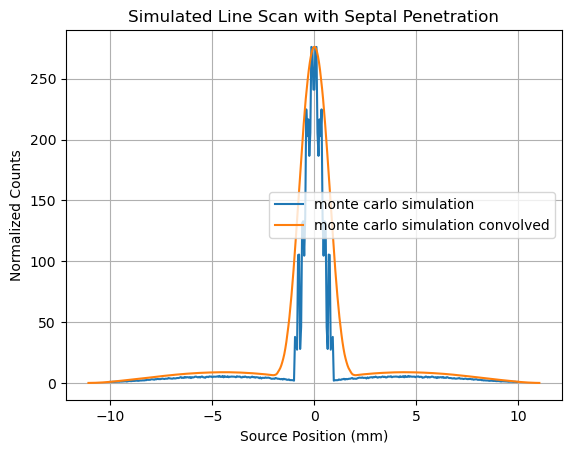

In [190]:
# print(len(x_scan))
# print(len(Signal_Modelled))


plt.plot(x_scan, Signal_Modelled, label="monte carlo simulation")
plt.plot(convolvedX, convolvedSignal, label="monte carlo simulation convolved")
plt.title("Simulated Line Scan with Septal Penetration")
plt.xlabel("Source Position (mm)")
plt.ylabel("Normalized Counts")
plt.legend()
plt.grid(True)
plt.show()

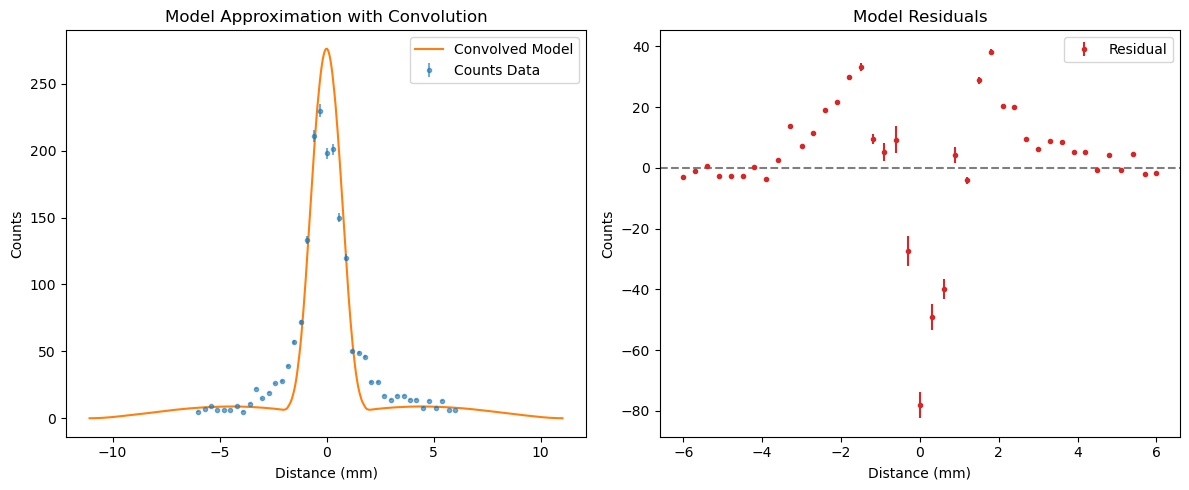

In [191]:
dist_array, counts_array, ucounts_array = m.readLineScan("./data/Lead Linescans - Feb 4/Feb 4, 2026, 3_25 PM, Scan1, 0_0 Deg, w-2mm.dat")

# print(max(convolvedSignal))

m.displayModelDataLinescan(convolvedX, convolvedSignal, dist_array, counts_array, ucounts_array, "Combined Convoluted Model+Residual - lead linescan.png")